In [5]:
import os
os.environ['KAGGLE_USERNAME'] = 'zuhairmalik'
os.environ['KAGGLE_KEY'] = '1e035b7e15136'

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from kaggle.api.kaggle_api_extended import KaggleApi

In [7]:
api = KaggleApi()
api.authenticate()

In [8]:
api.dataset_download_files('feyzazkefe/trashnet', path='./data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [10]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [11]:
def load_and_split_data(data_dir, train_ratio=0.7, val_ratio=0.15):
    """Split data into train, validation, and test sets"""
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
    
    # Calculate lengths for splits
    total_size = len(full_dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size
    
    # Split the dataset
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size]
    )
    
    # Apply correct transforms
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    test_dataset.dataset.transform = val_transform
    
    return train_dataset, val_dataset, test_dataset

In [12]:
class TrashClassifier(nn.Module):
    def __init__(self, num_classes):
        super(TrashClassifier, self).__init__()
        self.resnet = models.resnet34(pretrained=True)
        
        # Freeze early layers
        for param in list(self.resnet.parameters())[:-4]:
            param.requires_grad = False
            
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    """Training function with validation"""
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = val_correct / val_total
        val_losses.append(val_epoch_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")
        print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")
        
        # Save best model
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            torch.save(model.state_dict(), 'best_model.pth')
    
    return train_losses, val_losses

In [14]:
def evaluate_model(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Generate classification report
    class_names = test_loader.dataset.dataset.classes
    report = classification_report(all_labels, all_preds, target_names=class_names)
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return report
    

In [15]:
def main():
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    np.random.seed(42)
    
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load and split data
    train_dataset, val_dataset, test_dataset = load_and_split_data('./data/dataset-resized')
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
    
    # Initialize model
    num_classes = len(train_dataset.dataset.classes)
    model = TrashClassifier(num_classes).to(device)
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    
    # Train model
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, 
        num_epochs=20, device=device
    )
    
    # Load best model and evaluate
    model.load_state_dict(torch.load('best_model.pth'))
    test_report = evaluate_model(model, test_loader, device)
    print("\nTest Set Performance:")
    print(test_report)

/home/zuhair/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zuhair/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20
Train Loss: 1.5298, Train Acc: 0.4135
Val Loss: 1.0986, Val Acc: 0.6491
Epoch 2/20
Train Loss: 1.0709, Train Acc: 0.6024
Val Loss: 0.8701, Val Acc: 0.7098
Epoch 3/20
Train Loss: 0.9001, Train Acc: 0.6799
Val Loss: 0.7644, Val Acc: 0.7546
Epoch 4/20
Train Loss: 0.8240, Train Acc: 0.7053
Val Loss: 0.7346, Val Acc: 0.7467
Epoch 5/20
Train Loss: 0.7783, Train Acc: 0.7087
Val Loss: 0.6603, Val Acc: 0.7731
Epoch 6/20
Train Loss: 0.7296, Train Acc: 0.7336
Val Loss: 0.6462, Val Acc: 0.7757
Epoch 7/20
Train Loss: 0.7035, Train Acc: 0.7404
Val Loss: 0.6395, Val Acc: 0.7810
Epoch 8/20
Train Loss: 0.6941, Train Acc: 0.7528
Val Loss: 0.6674, Val Acc: 0.7467
Epoch 9/20
Train Loss: 0.6927, Train Acc: 0.7528
Val Loss: 0.5864, Val Acc: 0.8021
Epoch 10/20
Train Loss: 0.6405, Train Acc: 0.7658
Val Loss: 0.6038, Val Acc: 0.7942
Epoch 11/20
Train Loss: 0.6757, Train Acc: 0.7551
Val Loss: 0.5963, Val Acc: 0.7757
Epoch 12/20
Train Loss: 0.6606, Train Acc: 0.7500
Val Loss: 0.5637, Val Acc: 0.8074
E

/tmp/ipykernel_25466/16210281.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


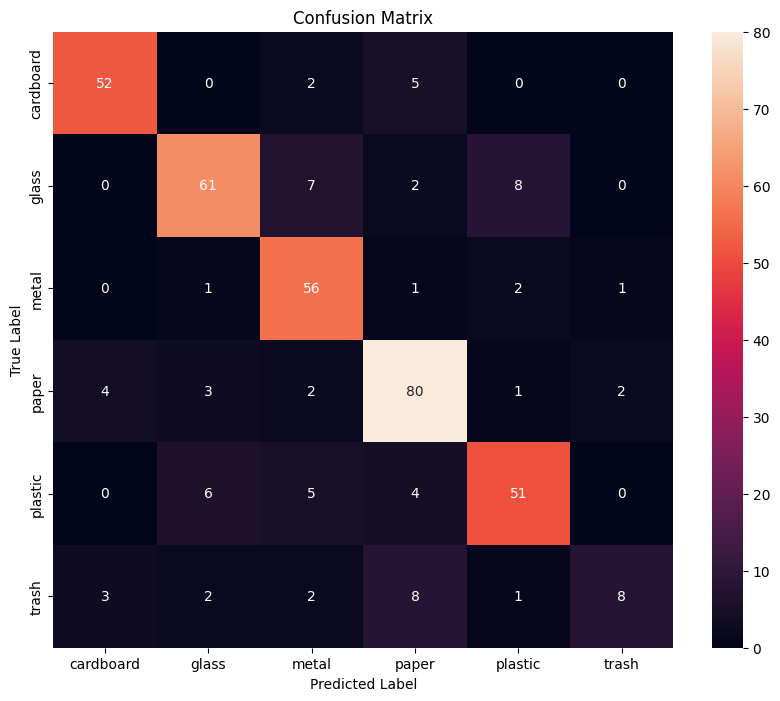


Test Set Performance:
              precision    recall  f1-score   support

   cardboard       0.88      0.88      0.88        59
       glass       0.84      0.78      0.81        78
       metal       0.76      0.92      0.83        61
       paper       0.80      0.87      0.83        92
     plastic       0.81      0.77      0.79        66
       trash       0.73      0.33      0.46        24

    accuracy                           0.81       380
   macro avg       0.80      0.76      0.77       380
weighted avg       0.81      0.81      0.80       380



In [16]:
if __name__ == "__main__":
    main()
    model.predict("test1.jpg")

In [17]:
model.predict("test1.jpg")

NameError: name 'model' is not defined